## Imports

In [407]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.feature_selection import SelectKBest, f_classif

## Load Dataset

In [408]:
# Load features and target
X = pd.read_csv("features_extracted.csv")
y = pd.read_csv("target_variable.csv").squeeze()  # Assuming target_variable.csv has a single column

# Load original dataset (audio features live here)
df = pd.read_csv("lyrics_preprocessed.csv") 

# --- Clean indices ---
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
df = df.reset_index(drop=True)

print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("df:", df.shape)

Shapes:
X: (682, 2643)
y: (682,)
df: (682, 23)


In [409]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics', 'language', 'lyrics_length', 'lyrics_clean',
       'word_count', 'lyrics_preproc_v2', 'tokens'],
      dtype='str')

In [410]:
# Sanity checks

# Same number of rows
assert X.shape[0] == y.shape[0], "X and y have different number of rows!"

# Index alignment
assert X.index.equals(y.index), "X and y indices are not aligned!"

print("Basic alignment between X and y is correct.")

Basic alignment between X and y is correct.


## Feature Groups

In [411]:
print(X.columns[:20])
print(len(X.columns))

Index(['ttr', 'avg_word_length', 'repetition_ratio', 'max_word_freq',
       'sentiment_polarity', 'abandoned', 'account', 'ace', 'across', 'act',
       'act like', 'actin', 'actin like', 'action', 'actually', 'add',
       'addict', 'addicted', 'addiction', 'address'],
      dtype='str')
2643


In [412]:
linguistic_cols = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]

# Separate TF-IDF features
tfidf_cols = [col for col in X.columns if col not in linguistic_cols]

X_ling = X[linguistic_cols]
X_tfidf = X[tfidf_cols]

# Combined lyrics model
X_combined = X.copy()

## TI-IDF Feature Selection

In [413]:
print(X_tfidf.isna().sum().sum())
print(y.isna().sum())

0
0


In [414]:
# --- Feature selection ONLY on training data ---
k = 1000
selector = SelectKBest(score_func=f_classif, k=k)

# Fit ONLY on train
X_tfidf_train_selected = selector.fit_transform(X_tfidf_train, y_train)

# Transform test
X_tfidf_test_selected = selector.transform(X_tfidf_test)

# Convert back to DataFrame
selected_features = X_tfidf_train.columns[selector.get_support()]

X_tfidf_train_selected = pd.DataFrame(
    X_tfidf_train_selected,
    columns=selected_features,
    index=X_tfidf_train.index
)

X_tfidf_test_selected = pd.DataFrame(
    X_tfidf_test_selected,
    columns=selected_features,
    index=X_tfidf_test.index
)
print("Selected TF-IDF shape:", X_tfidf_train_selected.shape)

Selected TF-IDF shape: (545, 1000)


In [415]:
# --- PURE TF-IDF selected ---
X_selected_train = X_tfidf_train_selected
X_selected_test  = X_tfidf_test_selected

# --- COMBINED (linguistic + selected TF-IDF) ---
X_combined_selected_train = pd.concat(
    [X_ling_train, X_tfidf_train_selected],
    axis=1
)

X_combined_selected_test = pd.concat(
    [X_ling_test, X_tfidf_test_selected],
    axis=1
)

## Lyrics + Audio Model

In [416]:
audio_cols = [
    "danceability","energy","valence","tempo",
    "loudness","speechiness","acousticness","instrumentalness"
]

# --- ALIGNMENT LOGIC ---
# reset_index → clean ordering
# .loc[X.index] → enforce alignment
# concat → safe merge

X_audio = df.loc[X.index, audio_cols]

# Final dataset
X_lyrics_audio = pd.concat(
    [X.reset_index(drop=True),
     X_audio.reset_index(drop=True)],
    axis=1
)

print("Lyrics + Audio shape:", X_lyrics_audio.shape)

Lyrics + Audio shape: (682, 2651)


In [417]:
print(X.index.equals(df.index))

True


In [418]:
print(X.shape)
print(df.shape)
print(X.index[:5])
print(df.index[:5])

(682, 2643)
(682, 23)
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


In [419]:
print(df.loc[X.index].head())
print(df.head())

               spotify_id                                           name  \
0  4KULAymBBJcPRpk1yO4dOG  I Remember Everything (feat. Kacey Musgraves)   
1  7KA4W4McWYRpgf0fWsJZWB               See You Again (feat. Kali Uchis)   
2  17phhZDn6oGtzMe56NuWvj                                   Lose Control   
3  4iZ4pt7kvcaH6Yo8UoZ4s2                                         Snooze   
4  1Qrg8KqiBpW07V7PNxwwwL                                      Kill Bill   

                          artists                                  album_name  \
0     Zach Bryan, Kacey Musgraves                                  Zach Bryan   
1  Tyler, The Creator, Kali Uchis                                  Flower Boy   
2                     Teddy Swims  I've Tried Everything But Therapy (Part 1)   
3                             SZA                                         SOS   
4                             SZA                                         SOS   

  album_release_date  danceability  energy  valence    t

In [420]:
# Sanity checks

# Same number of rows
assert X_audio.shape[0] == X.shape[0], "Audio and X rows mismatch!"

# Check for missing values
print("Missing values in audio:", X_audio.isnull().sum().sum())

# Quick inspection
print("\nFirst row check:")
print("Lyrics features (first row):")
print(X.iloc[0].head())

print("\nAudio features (first row):")
print(X_audio.iloc[0])

Missing values in audio: 0

First row check:
Lyrics features (first row):
ttr                  -0.368533
avg_word_length       0.534703
repetition_ratio     -0.803045
max_word_freq        -0.752791
sentiment_polarity    0.850796
Name: 0, dtype: float64

Audio features (first row):
danceability         0.429000
energy               0.453000
valence              0.155000
tempo               77.639000
loudness            -7.746000
speechiness          0.045900
acousticness         0.554000
instrumentalness     0.000002
Name: 0, dtype: float64


## Model Function

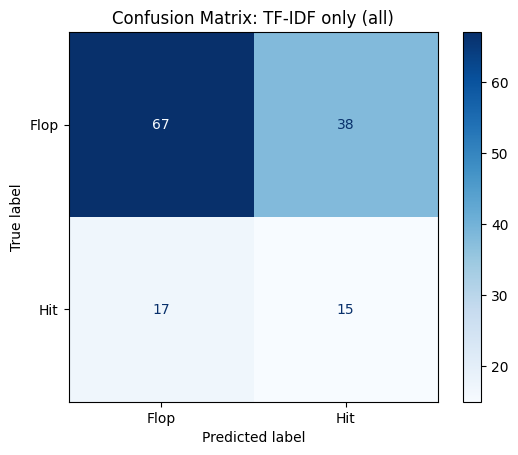

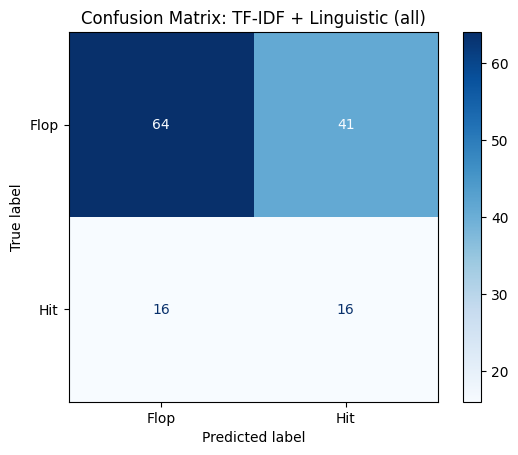

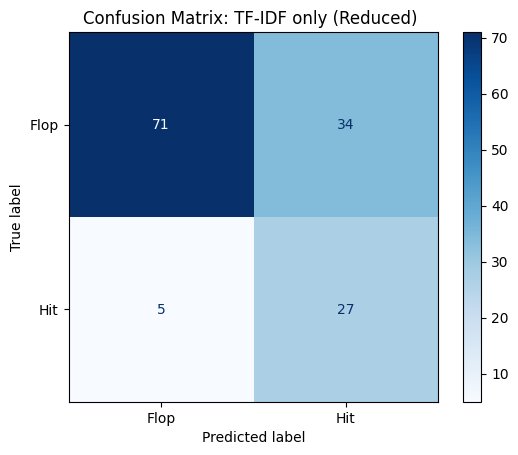

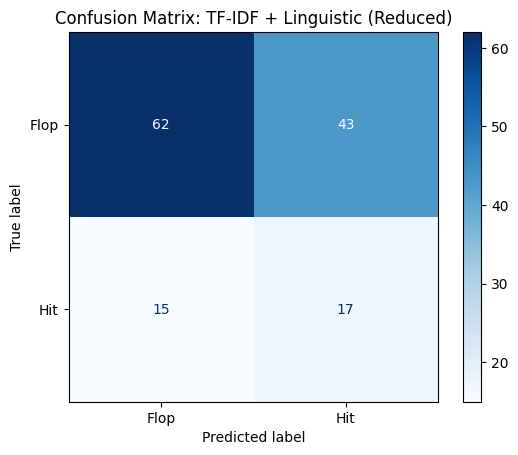

                               Precision   Recall        F1   ROC-AUC
Model                                                                
TF-IDF only (all)               0.283019  0.46875  0.352941  0.541964
TF-IDF + Linguistic (all)       0.280702  0.50000  0.359551  0.557738
TF-IDF only (Reduced)           0.442623  0.84375  0.580645  0.831845
TF-IDF + Linguistic (Reduced)   0.283333  0.53125  0.369565  0.575298


In [421]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

def evaluate_model(X_train, X_test, y_train, y_test, name):
    model = LogisticRegression(
        solver="liblinear",
        max_iter=5000,
        C=10,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    threshold = 0.3
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Flop", "Hit"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    return {
        "Model":     name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
    }

# ── Split ONCE on indices ──────────────────────────────────────
from sklearn.model_selection import train_test_split

idx_train, idx_test = train_test_split(
    np.arange(len(y)),
    test_size=0.2,
    stratify=y,
    random_state=42
)
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

# ── Split each X using same indices ───────────────────────────
def split_X(X, idx_train, idx_test):
    if issparse(X):
        return X[idx_train], X[idx_test]       # sparse matrix
    return X.iloc[idx_train], X.iloc[idx_test]  # dense DataFrame

X_ling_train,      X_ling_test      = split_X(X_ling,             idx_train, idx_test)
X_tfidf_train,     X_tfidf_test     = split_X(X_tfidf,            idx_train, idx_test)
X_combined_train,  X_combined_test  = split_X(X_combined,         idx_train, idx_test)
X_lyrics_train,    X_lyrics_test    = split_X(X_lyrics_audio,     idx_train, idx_test)
X_selected_train,  X_selected_test  = split_X(X_combined_selected,idx_train, idx_test)

# ── Evaluate all on same test set ─────────────────────────────
results_list = []

# results_list.append(evaluate_model(X_ling_train, X_ling_test, y_train, y_test, "Linguistic Features"))
results_list.append(evaluate_model(X_tfidf_train, X_tfidf_test, y_train, y_test, "TF-IDF only (all)"))
results_list.append(evaluate_model(X_combined_train, X_combined_test, y_train, y_test, "TF-IDF + Linguistic (all)"))
# results_list.append(evaluate_model(X_lyrics_train, X_lyrics_test, y_train, y_test, "Lyrics + Audio Model"))
results_list.append(evaluate_model(X_selected_train, X_selected_test, y_train, y_test, "TF-IDF only (Reduced) "))
results_list.append(evaluate_model(X_combined_selected_train, X_combined_selected_test, y_train, y_test, "TF-IDF + Linguistic (Reduced)"))

results_df = pd.DataFrame(results_list).set_index("Model")
print(results_df)

## Train all models

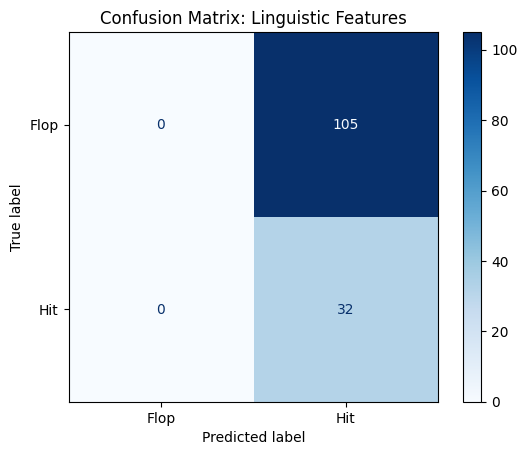

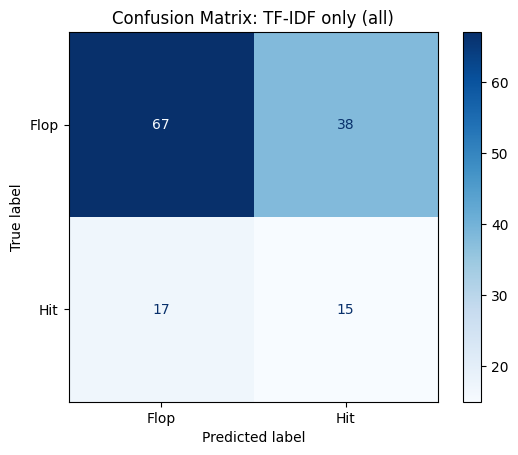

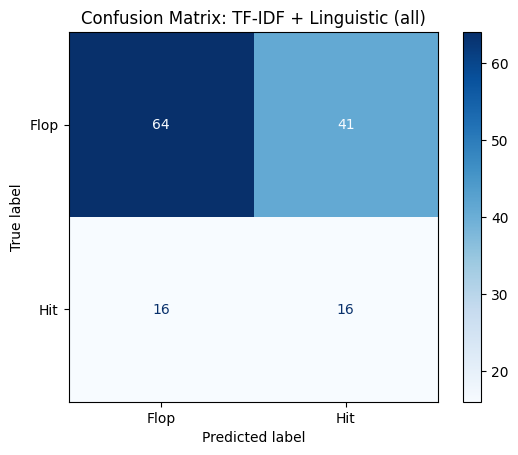

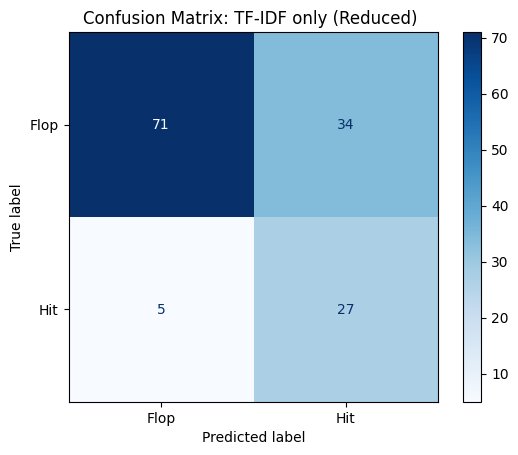

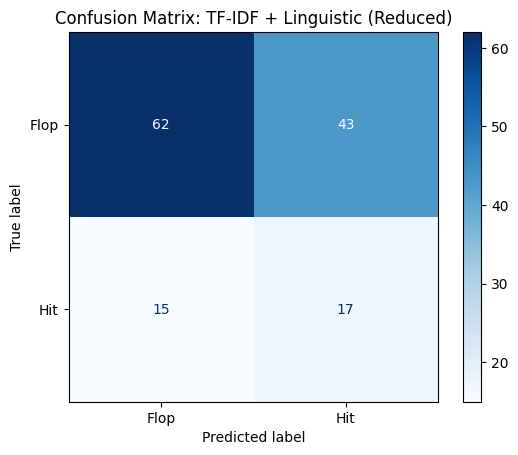

In [436]:
results_list = []

results_list.append(evaluate_model(X_ling_train,     X_ling_test,     y_train, y_test, "Linguistic Features"))
results_list.append(evaluate_model(X_tfidf_train,    X_tfidf_test,    y_train, y_test, "TF-IDF only (all)"))
results_list.append(evaluate_model(X_combined_train, X_combined_test, y_train, y_test, "TF-IDF + Linguistic (all)"))
# results_list.append(evaluate_model(X_lyrics_train,   X_lyrics_test,   y_train, y_test, "Lyrics + Audio Model"))
results_list.append(evaluate_model(X_selected_train, X_selected_test, y_train, y_test, "TF-IDF only (Reduced) "))
results_list.append(evaluate_model(X_combined_selected_train, X_combined_selected_test, y_train, y_test, "TF-IDF + Linguistic (Reduced)"))

## Results

In [437]:
results = pd.DataFrame(results_list)
results = results.sort_values(by="ROC-AUC", ascending=False)

results

,Model,Precision,Recall,F1,ROC-AUC
3,TF-IDF only (Reduced),0.442623,0.84375,0.580645,0.831845
4,TF-IDF + Linguistic (Reduced),0.283333,0.53125,0.369565,0.575298
0,Linguistic Features,0.233577,1.00000,0.378698,0.563393
2,TF-IDF + Linguistic (all),0.280702,0.50000,0.359551,0.557738
1,TF-IDF only (all),0.283019,0.46875,0.352941,0.541964


In [424]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd

### Visual comparison of ROC-AUC scores

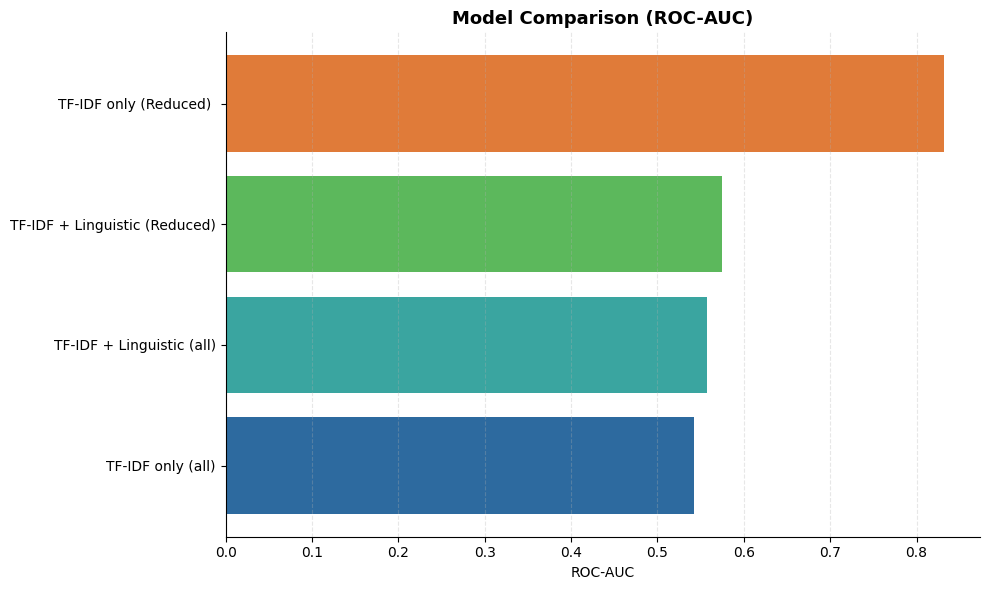

In [430]:
# ── Plot ────────────────────────────────────────────────────
palette = ["#2D6A9F", "#3AA5A0", "#5CB85C", "#E07B39", "#9B59B6", "#6C757D"]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Sort values for cleaner visualization
sorted_results = results.sort_values("ROC-AUC")

axes.barh(
    sorted_results["Model"],
    sorted_results["ROC-AUC"],
    color=palette[:len(sorted_results)]
)

axes.set_title(
    "Model Comparison (ROC-AUC)",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("ROC-AUC")
axes.set_ylabel("")

# ── Clean spines only, keep background ───────────────────────
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

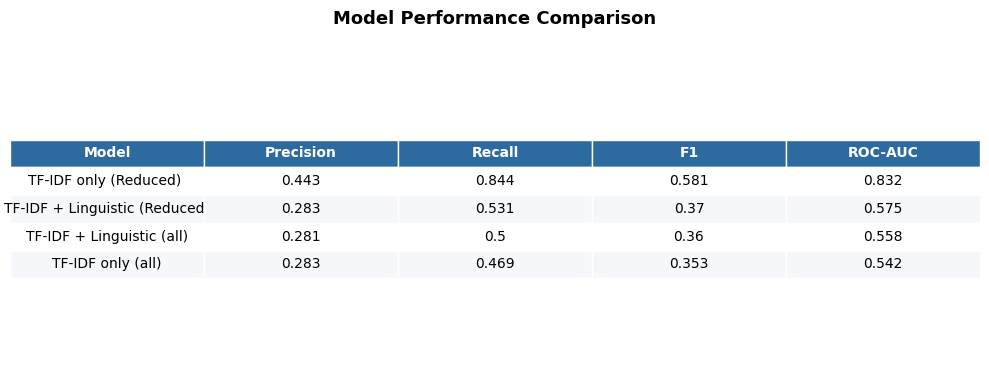

In [432]:
import matplotlib.pyplot as plt

# Sort and round
sorted_results = results.sort_values("ROC-AUC", ascending=False).round(3)

fig, ax = plt.subplots(figsize=(10, 4))

# Remove axes
ax.axis("off")

# Create table (NO rowLabels)
table = ax.table(
    cellText=sorted_results.values,
    colLabels=sorted_results.columns,
    loc="center",
    cellLoc="center"
)

# ── Styling ────────────────────────────────────────────────
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

header_color = "#2D6A9F"
row_color = "#FFFFFF"
alt_row_color = "#F5F7FA"

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")
        cell.set_edgecolor("white")
    else:
        cell.set_facecolor(row_color if row % 2 == 1 else alt_row_color)
        cell.set_edgecolor("white")

# Title
plt.title(
    "Model Performance Comparison",
    fontweight="bold",
    fontsize=13,
    pad=10
)

plt.tight_layout()
plt.savefig("model_table_clean.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation (best model)

In [426]:
model = LogisticRegression(solver="liblinear", max_iter=5000, C=10)
model.fit(X_selected_train, y_train)

coef = pd.Series(model.coef_[0], index=X_selected_train.columns)

### Linguistic features plot

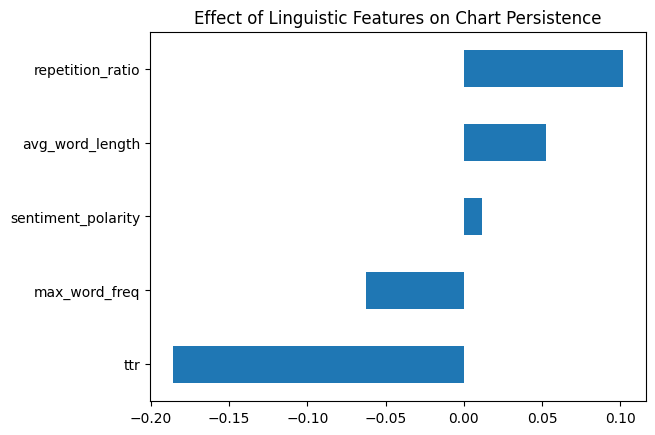

In [427]:
coef[linguistic_cols].sort_values().plot(kind="barh")
plt.title("Effect of Linguistic Features on Chart Persistence")
plt.show()

### TF-IDF Interpretation

In [428]:
coef_words = coef[X_tfidf_selected.columns]

# Remove repeated bigrams
coef_words = coef_words[~coef_words.index.str.match(r'^(\w+)\s+\1$')]

top_positive = coef_words.sort_values(ascending=False).head(20)
top_negative = coef_words.sort_values().head(20)

### Plot top words

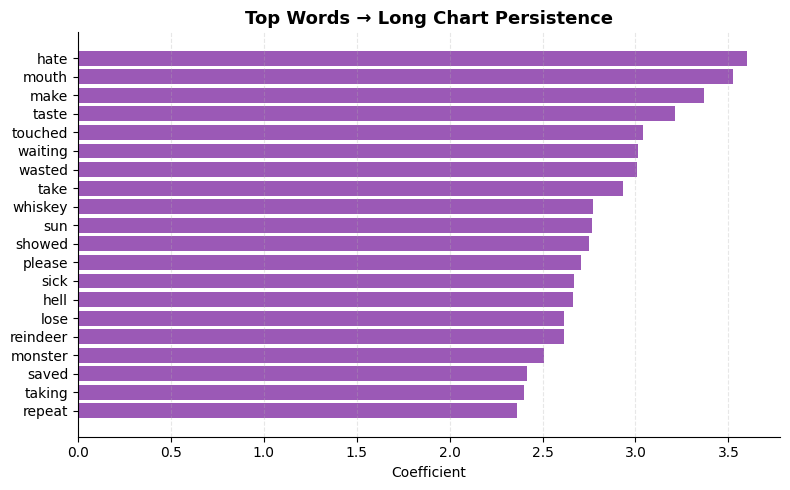

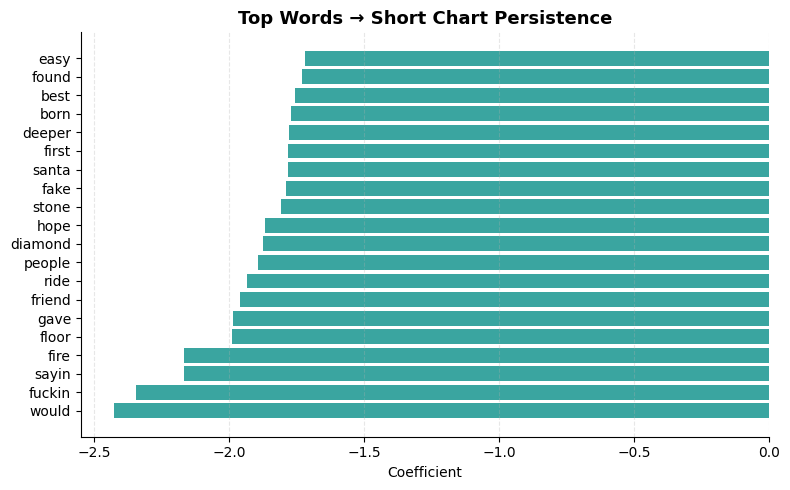

In [435]:
palette = ["#9B59B6"] * len(top_positive)

# ── Positive words ──────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.barh(
    top_positive.sort_values().index,
    top_positive.sort_values().values,
    color=palette
)

axes.set_title(
    "Top Words → Long Chart Persistence",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("Coefficient")
axes.set_ylabel("")

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("top_positive_words.png", dpi=300, bbox_inches="tight")
plt.show()


# ── Negative words ──────────────────────────────────────────
palette = ["#3AA5A0"] * len(top_negative)

fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.barh(
    top_negative.sort_values().index,
    top_negative.sort_values().values,
    color=palette
)

axes.set_title(
    "Top Words → Short Chart Persistence",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("Coefficient")
axes.set_ylabel("")

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("top_negative_words.png", dpi=300, bbox_inches="tight")
plt.show()